/tmp/ipykernel_9390/1723256361.py:61: RuntimeWarning: invalid value encountered in divide
  avg_heatmap = np.where(valid_pixel_counts > 0, sum_heatmap / valid_pixel_counts, 0)


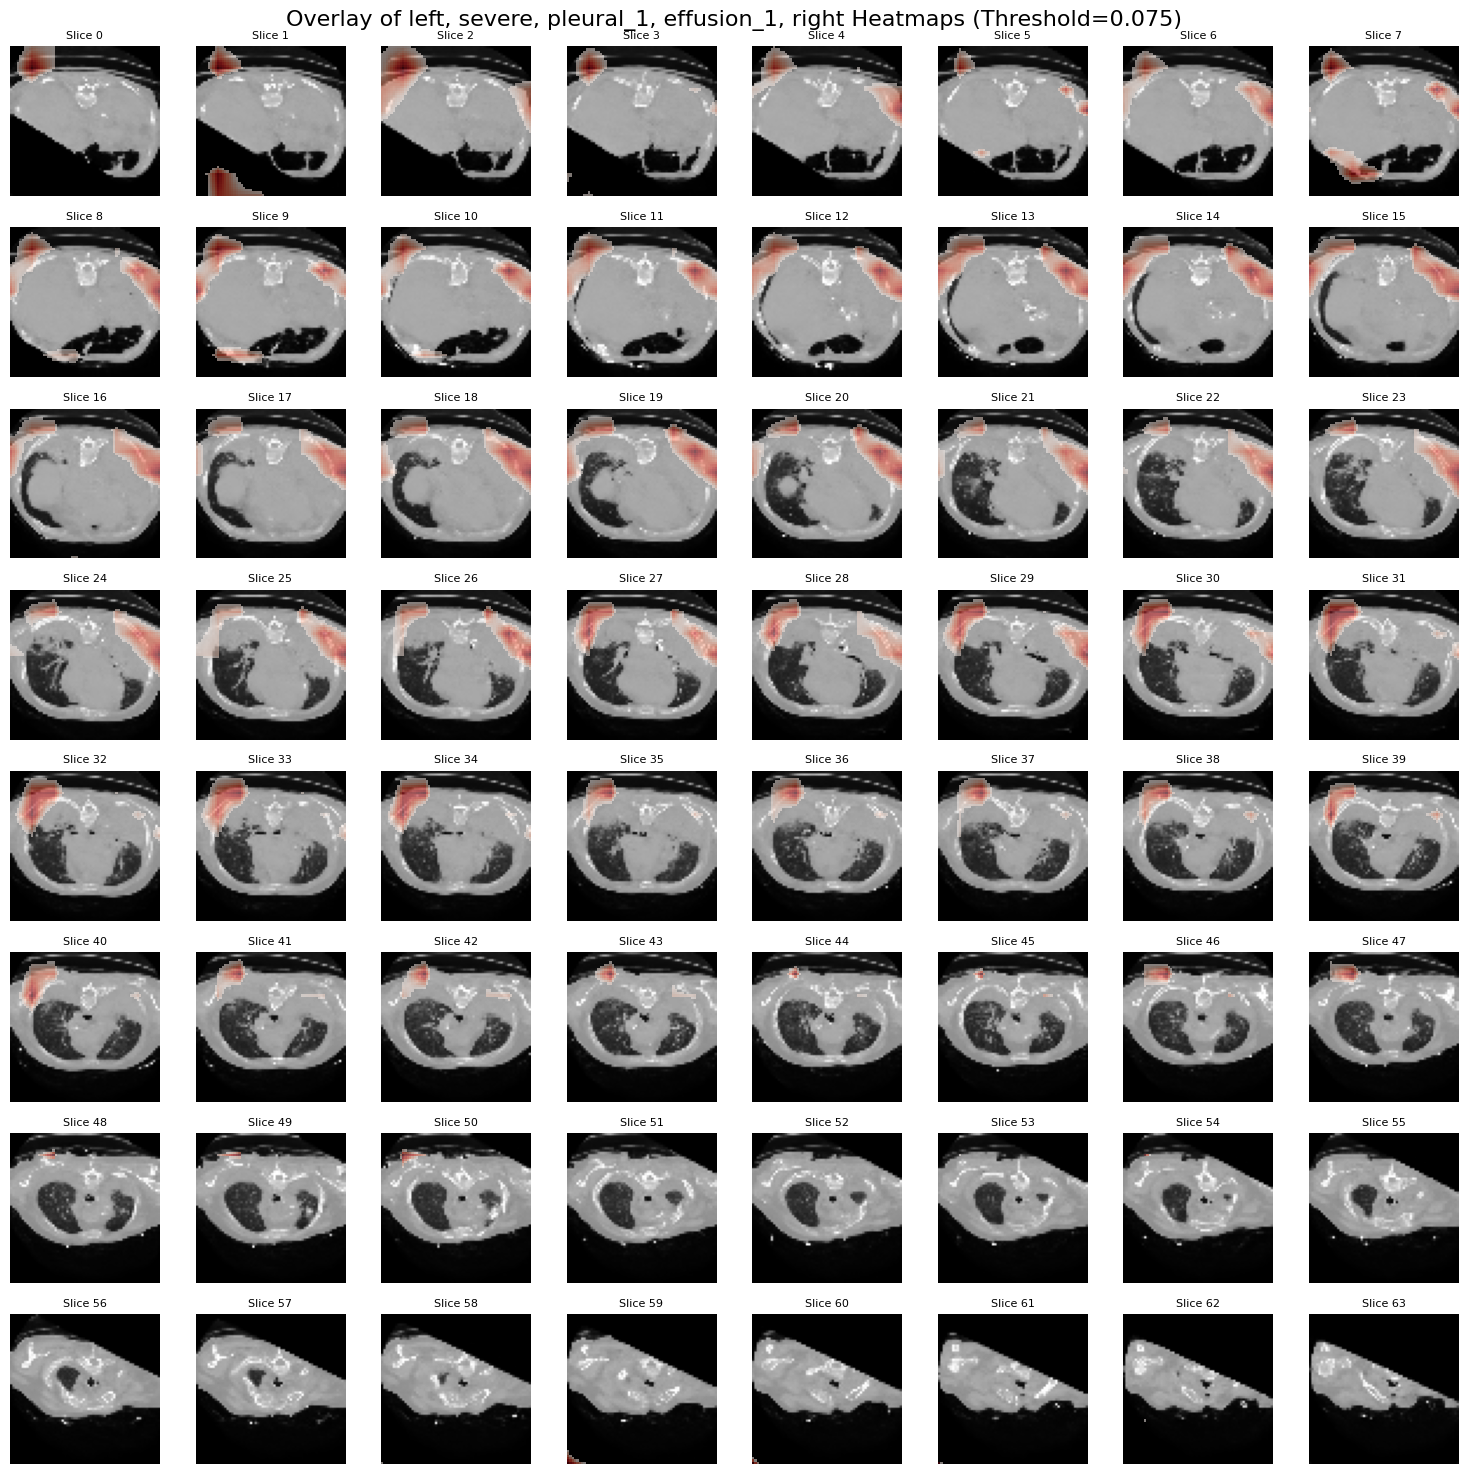

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.ndimage import zoom

ct_scan_path = "/media/volume/gen-ai-volume/MedSyn/results/img_64_standard/111222444/111222444_sample_0.npy"
heatmaps_folder = "/media/volume/gen-ai-volume/MedSyn/results/saliency_maps/111222444/"

heatmap_files = {
    "mild": "111222444_sample_0_token_1_mild_heatmaps.npy",
    "right": "111222444_sample_0_token_2_right_heatmaps.npy",
    "pleural_1": "111222444_sample_0_token_3_pleural_heatmaps.npy",
    "effusion_1": "111222444_sample_0_token_4_effusion_heatmaps.npy",
    "severe": "111222444_sample_0_token_6_severe_heatmaps.npy",
    "left": "111222444_sample_0_token_7_left_heatmaps.npy",
    "pleural_2": "111222444_sample_0_token_8_pleural_heatmaps.npy",
    "effusion_2": "111222444_sample_0_token_9_effusion_heatmaps.npy",
}

ct_volume = np.load(ct_scan_path) 
ct_slices = ct_volume[0, 0, :, :, :] 

def resize_heatmap(heatmap, target_shape=(64, 64, 64)):
    zoom_factors = (
        target_shape[0] / heatmap.shape[0],  # Depth
        target_shape[1] / heatmap.shape[1],  # Height
        target_shape[2] / heatmap.shape[2],  # Width
    )
    return zoom(heatmap, zoom_factors, order=1)  

selected_tokens = ["severe", "left", "pleural_1", "effusion_1"]
#selected_tokens = ["right"]   
heatmap_threshold = 0.075  
selected_tokens = list(set(selected_tokens))

heatmap_stack = []
valid_pixel_counts = np.zeros((64, 64, 64))  # Count valid pixels to avoid spreading noise

for token in selected_tokens:
    heatmap_path = os.path.join(heatmaps_folder, heatmap_files[token])

    if os.path.exists(heatmap_path):
        heatmap_data = np.load(heatmap_path)  # Shape: (64, 8, 8)
        resized_heatmap = resize_heatmap(heatmap_data, target_shape=(64, 64, 64))
        
        # Apply threshold to each heatmap separately before averaging
        thresholded_heatmap = np.where(resized_heatmap >= heatmap_threshold, resized_heatmap, 0)

        # Keep track of the number of valid pixels per voxel
        valid_pixel_counts += (thresholded_heatmap > 0).astype(np.float32)

        heatmap_stack.append(thresholded_heatmap)
    else:
        print(f"Heatmap file '{heatmap_path}' not found.")

if len(heatmap_stack) == 0:
    raise ValueError("No valid heatmaps selected.")

sum_heatmap = np.sum(np.stack(heatmap_stack, axis=0), axis=0)

avg_heatmap = np.where(valid_pixel_counts > 0, sum_heatmap / valid_pixel_counts, 0)

def overlay_binary_heatmap_on_ct(ct_scan, heatmap, title):
    fig, axes = plt.subplots(8, 8, figsize=(15, 15))
    axes = axes.flatten()

    for i in range(64):
        ct_slice_norm = (ct_scan[i, :, :] - np.min(ct_scan[i, :, :])) / (
            np.max(ct_scan[i, :, :]) - np.min(ct_scan[i, :, :]) + 1e-8
        )  

        heatmap_slice = heatmap[i, :, :]  

        axes[i].imshow(ct_slice_norm, cmap="gray")  
        if np.any(heatmap_slice > 0):  
            heatmap_masked_slice = np.ma.masked_where(heatmap_slice <= 0, heatmap_slice)
            axes[i].imshow(heatmap_masked_slice, cmap="Reds", alpha=0.5, interpolation="nearest")  

        axes[i].set_title(f"Slice {i}", fontsize=8)
        axes[i].axis("off")

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

overlay_binary_heatmap_on_ct(
    ct_slices,
    avg_heatmap,
    title=f"Overlay of {', '.join(selected_tokens)} Heatmaps (Threshold={heatmap_threshold})"
)
